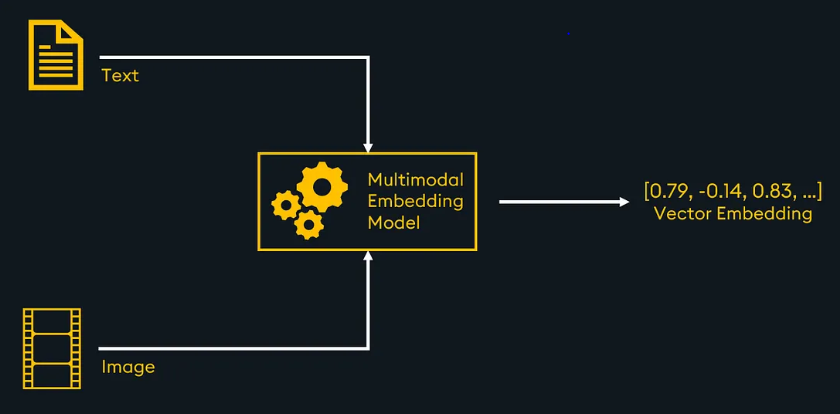

In [ ]:
# !pip install faiss-cpu sentence-transformers pillow matplotlib openai

In [2]:
import os
import google.generativeai as genai

c:\Users\jagad\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [ ]:
# 1. Setup API Key
os.environ["GEMINI_API_KEY"] = ""  # Replace this
genai.configure(api_key=os.environ["GEMINI_API_KEY"])

# 2. Initialize Model
# We use the model object directly as you requested
llm = genai.GenerativeModel('gemini-2.5-flash') 

# Note: 'gemini-2.5-flash' is primarily supported in the NEW SDK. 
# If 'gemini-2.5-flash' gives an error here, switch to 'gemini-1.5-flash' 
# or 'gemini-1.5-pro', which are fully stable in this library.

print("Legacy GenAI Configured!")

Legacy GenAI Configured!


In [4]:
import faiss
import numpy as np
from PIL import Image, ImageDraw
from sentence_transformers import SentenceTransformer

# 1. Generate Dummy Images
dataset_path = "legacy_rag_images"
os.makedirs(dataset_path, exist_ok=True)

def create_shape(name, color, shape):
    img = Image.new('RGB', (200, 200), 'white')
    d = ImageDraw.Draw(img)
    if shape == 'circle': d.ellipse([50, 50, 150, 150], fill=color)
    elif shape == 'rect': d.rectangle([50, 50, 150, 150], fill=color)
    img.save(os.path.join(dataset_path, name))
    return os.path.join(dataset_path, name)

create_shape("imgA.jpg", "red", "circle")
create_shape("imgB.jpg", "blue", "rect")
create_shape("imgC.jpg", "green", "circle")

# 2. Load Embedder
embedder = SentenceTransformer('clip-ViT-B-32')

# 3. Index
stored_paths = []
vectors = []
for file in os.listdir(dataset_path):
    if file.endswith(".jpg"):
        path = os.path.join(dataset_path, file)
        img = Image.open(path)
        vectors.append(embedder.encode(img))
        stored_paths.append(path)

index = faiss.IndexFlatL2(512)
index.add(np.array(vectors).astype('float32'))
print("Indexing Complete.")

c:\Users\jagad\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jagad\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installe

Indexing Complete.


Searching for 4 images...
Match 1: legacy_rag_images\imgA.jpg
Match 2: legacy_rag_images\imgC.jpg
Match 3: legacy_rag_images\imgB.jpg

Gemini Answer:
 The red colored object is a **circle**.


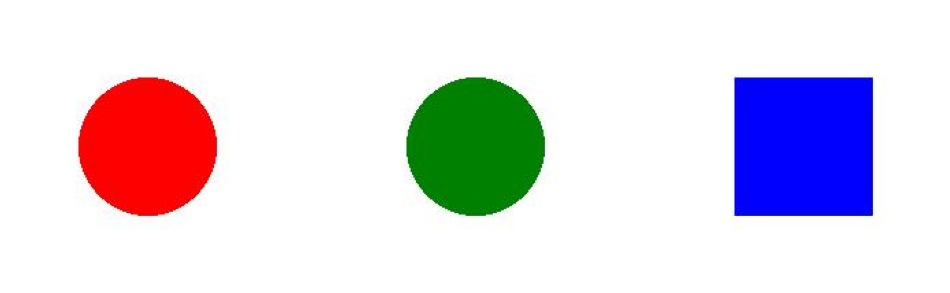

In [10]:
import PIL.Image

def ask_legacy_rag_multiple(query, k=4):
    # 1. Retrieve (Find top k images)
    query_vec = embedder.encode([query]).astype('float32')
    
    # Search FAISS for top k matches
    # indices[0] is a list of the top k IDs (e.g., [2, 0, 5, 1])
    distances, indices = index.search(query_vec, k=k)
    
    retrieved_images = []
    print(f"Searching for {k} images...")
    
    # 2. Loop through the results to collect actual images
    for i, idx in enumerate(indices[0]):
        # FAISS returns -1 if it can't find enough matches
        if idx != -1:
            path = stored_paths[idx]
            print(f"Match {i+1}: {path}")
            img = PIL.Image.open(path)
            retrieved_images.append(img)
            
    if not retrieved_images:
        return "No images found.", []

    # 3. Generate (Send Text + List of Images to Gemini)
    # We create a list: [Query Text, Image1, Image2, Image3, Image4]
    content_payload = [query, "Analyze these images together:"] + retrieved_images
    
    response = llm.generate_content(content_payload)
    
    return response.text, retrieved_images

# --- RUN IT ---
# Ask about the collection of images
query = "what is shape of red colored object"

answer, images = ask_legacy_rag_multiple(query, k=4)

print("\n" + "="*30)
print("Gemini Answer:\n", answer)
print("="*30)

# Optional: Display them to verify
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(images), figsize=(12, 4))
if len(images) == 1: axes = [axes] # Handle single image case
for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')
plt.show()

In [11]:
import os
import zipfile
import urllib.request

# Define paths
dataset_dir = "flickr8k_dataset"
images_dir = os.path.join(dataset_dir, "images")
zip_path = "flickr8k.zip"

# URL for Flickr8k (Mirror)
url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"

def download_and_extract():
    if os.path.exists(images_dir):
        print("Dataset already exists. Skipping download.")
        return

    print("Downloading Dataset (approx 1GB)... this may take a minute.")
    urllib.request.urlretrieve(url, zip_path)
    
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
        
    # Cleanup zip to save space
    os.remove(zip_path)
    
    # Handle folder structure (sometimes it extracts into a subfolder)
    # We ensure all images are in 'flickr8k_dataset/images'
    extracted_folder = os.path.join(dataset_dir, "Flicker8k_Dataset")
    if os.path.exists(extracted_folder):
        os.rename(extracted_folder, images_dir)
        
    print(f"Dataset ready! Images located in: {images_dir}")

download_and_extract()

Extracting...
Dataset ready! Images located in: flickr8k_dataset\images


In [4]:
import chromadb
from chromadb.config import Settings

# 1. Initialize Persistent Client (Saves to disk)
# This creates a folder 'flickr_chroma_db' in your project directory
client = chromadb.PersistentClient(path="flickr_chroma_db")

# 2. Create Collection (Like a Table)
# Chroma handles the vector dimension automatically based on the data you pass
collection = client.get_or_create_collection(name="flickr_images")

print("ChromaDB initialized for Windows!")

ChromaDB initialized for Windows!


In [5]:
import os
from PIL import Image
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# Load Model
model = SentenceTransformer('clip-ViT-B-32')

def ingest_to_chroma(image_folder, batch_size=64):
    # 1. CRITICAL FIX: Convert to Absolute Path immediately
    # This ensures ChromaDB knows exactly where the file is on your hard drive
    abs_image_folder = os.path.abspath(image_folder)
    
    if not os.path.exists(abs_image_folder):
        print(f"❌ Error: The folder '{abs_image_folder}' does not exist!")
        return

    valid_extensions = ('.jpg', '.jpeg', '.png')
    all_files = [f for f in os.listdir(abs_image_folder) if f.endswith(valid_extensions)]
    
    print(f"Found {len(all_files)} images in: {abs_image_folder}")
    print("Indexing...")
    
    # Buffers
    ids_batch = []
    embeddings_batch = []
    metadatas_batch = []
    
    for i, filename in enumerate(tqdm(all_files)):
        try:
            # 2. Use the Absolute Path here
            full_path = os.path.join(abs_image_folder, filename)
            
            # Verify image opens correctly
            img = Image.open(full_path)
            
            # Encode
            vector = model.encode(img).tolist()
            
            # Add to batch buffers
            ids_batch.append(filename) 
            embeddings_batch.append(vector)
            
            # 3. Store the FULL PATH in metadata
            metadatas_batch.append({"path": full_path})
            
            # Insert when batch is full
            if len(ids_batch) >= batch_size:
                collection.add(
                    ids=ids_batch,
                    embeddings=embeddings_batch,
                    metadatas=metadatas_batch
                )
                # Clear buffers
                ids_batch = []
                embeddings_batch = []
                metadatas_batch = []

        except Exception as e:
            print(f"Skipping {filename}: {e}")
            
    # Insert remaining
    if ids_batch:
        collection.add(
            ids=ids_batch,
            embeddings=embeddings_batch,
            metadatas=metadatas_batch
        )
    
    print("✅ Ingestion Complete! Data saved with Absolute Paths.")

# --- RUN IT ---
# Even if you type a relative path here, the function will now convert it to Absolute
ingest_to_chroma("flickr8k_dataset\\images")

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/clip-ViT-B-32/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002251770F640>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: aaf35580-fff0-4e58-b7aa-b84ab4c066b0)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/clip-ViT-B-32/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/clip-ViT-B-32/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000022517761420>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 917cbda0-95ed-4385-9a7a-19f5c6b417a4)')' thrown while requesting HEAD https://huggingface.co/senten

Found 538 images in: c:\Users\jagad\Documents\git_rep\self_projects\flickr8k_dataset\images
Indexing...


100%|██████████| 538/538 [01:15<00:00,  7.12it/s]

✅ Ingestion Complete! Data saved with Absolute Paths.


Fetching data from DB...
Calculating 2D map for 150 images...
Drawing images on canvas...


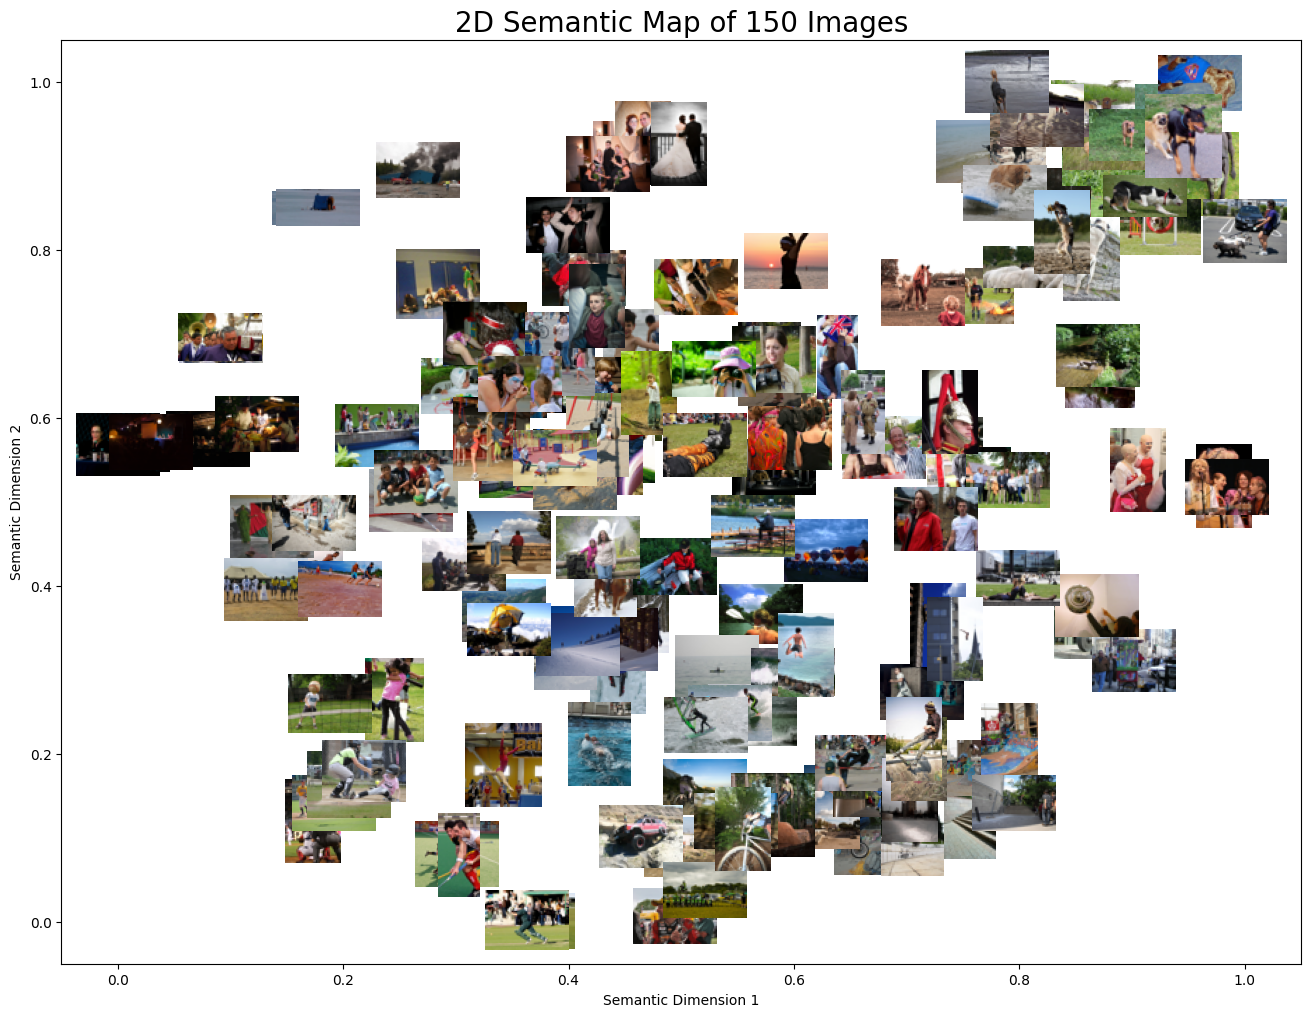

In [6]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.manifold import TSNE
import numpy as np
from PIL import Image

def visualize_collection_2d(max_images=100):
    # 1. Fetch Data from ChromaDB
    # We fetch IDs, Embeddings, and Metadata (paths)
    print("Fetching data from DB...")
    data = collection.get(include=['embeddings', 'metadatas'])
    
    if len(data['ids']) < 8:
        print("Not enough images to visualize! Add at least 5-10 images.")
        return

    # Limit the number of points for performance (t-SNE is slow on huge datasets)
    # We slice the lists to the max_images limit
    ids = data['ids'][:max_images]
    embeddings = data['embeddings'][:max_images]
    metadatas = data['metadatas'][:max_images]

    # 2. Reduce Dimensions (512 -> 2)
    # t-SNE is great for visualizing clusters of similar images
    print(f"Calculating 2D map for {len(embeddings)} images...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    coords = tsne.fit_transform(np.array(embeddings))

    # 3. Plotting
    tx = coords[:, 0]
    ty = coords[:, 1]

    # Normalize coordinates to 0-1 range for easier plotting
    tx = (tx - min(tx)) / (max(tx) - min(tx))
    ty = (ty - min(ty)) / (max(ty) - min(ty))

    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plot the scatter dots (invisible, just for structure)
    ax.scatter(tx, ty, alpha=0)

    # 4. Draw Images on the Plot
    print("Drawing images on canvas...")
    for i, (x_coord, y_coord) in enumerate(zip(tx, ty)):
        path = metadatas[i]['path']
        
        try:
            # Load and Resize Image
            img = Image.open(path)
            img.thumbnail((60, 60)) # Resize to small thumbnail
            
            # Create graph object
            imagebox = OffsetImage(img, zoom=1.0)
            ab = AnnotationBbox(imagebox, (x_coord, y_coord), frameon=False)
            ax.add_artist(ab)
        except Exception as e:
            print(f"Could not plot {path}: {e}")

    plt.title(f"2D Semantic Map of {len(embeddings)} Images", fontsize=20)
    plt.xlabel("Semantic Dimension 1")
    plt.ylabel("Semantic Dimension 2")
    plt.show()

# --- RUN IT ---
# Note: Keep max_images around 100-200. 
# If you plot 8000 images, they will overlap too much to see anything!
visualize_collection_2d(max_images=150)

🔎 Searching for: 'Find a picture of a child playing'...
✅ Found 3 images. Visualizing...


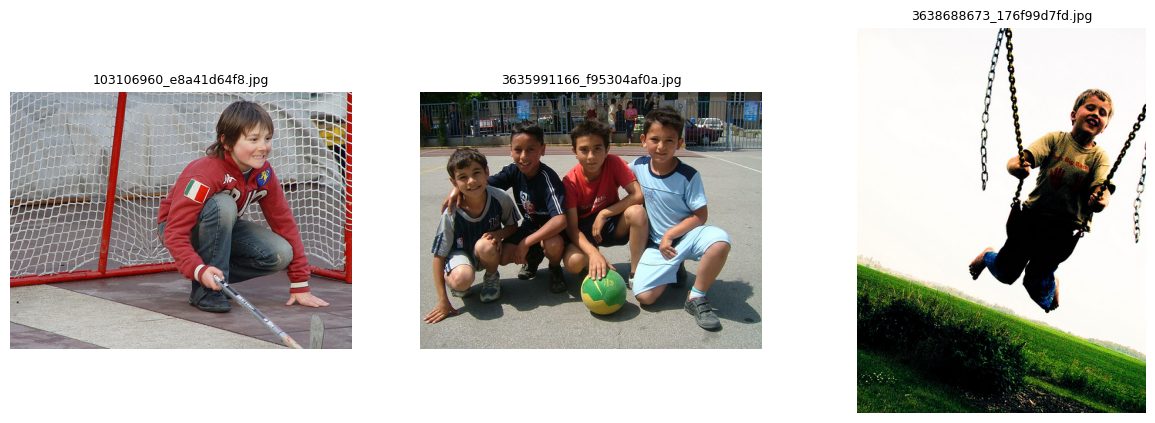

👇 If these images look correct, run the next cell to generate the answer.


In [7]:
# --- CELL A: SEARCH & VISUALIZE ---
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define your query here
USER_QUERY = "Find a picture of a child playing" 
TOP_K = 3

print(f"🔎 Searching for: '{USER_QUERY}'...")

# 2. Encode & Search Chroma
# (Assuming 'model' and 'collection' are defined from previous steps)
query_vector = model.encode([USER_QUERY]).tolist()

results = collection.query(
    query_embeddings=query_vector,
    n_results=TOP_K
)

# 3. Load Images
retrieved_context_images = [] # We store images here to use in the NEXT cell
filenames = []

if results['metadatas'][0]:
    for i, meta in enumerate(results['metadatas'][0]):
        path = meta['path']
        img = Image.open(path)
        retrieved_context_images.append(img)
        filenames.append(os.path.basename(path))
else:
    print("❌ No images found!")

# 4. VISUALIZE SEARCH RESULTS
if retrieved_context_images:
    print(f"✅ Found {len(retrieved_context_images)} images. Visualizing...")
    
    # Dynamic plot size based on number of images
    cols = len(retrieved_context_images)
    fig, axes = plt.subplots(1, cols, figsize=(15, 5))
    
    # Handle single image case (matplotlib quirk)
    if cols == 1: axes = [axes]
    
    for ax, img, fname in zip(axes, retrieved_context_images, filenames):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(fname, fontsize=9)
        
    plt.show()
    print("👇 If these images look correct, run the next cell to generate the answer.")

In [8]:
# --- CELL B: GENERATION (GEMINI) ---
import google.generativeai as genai
from IPython.display import Markdown, display

# # 1. Setup Gemini (Ensuring it's connected)
# os.environ["GEMINI_API_KEY"] = "YOUR_GOOGLE_API_KEY_HERE"
# genai.configure(api_key=os.environ["GEMINI_API_KEY"])
# llm = genai.GenerativeModel('gemini-1.5-flash')

# 2. Check if we have images from Cell A
if 'retrieved_context_images' not in globals() or not retrieved_context_images:
    print("⚠️ No images found! Please run Cell A first.")
else:
    print("🤖 Sending images to Gemini for analysis...")
    
    # 3. Construct Payload
    # We use the USER_QUERY from Cell A and the images we found
    prompt_payload = [USER_QUERY, "Analyze the provided images to answer the user request detailedly."] + retrieved_context_images
    
    # 4. Generate
    response = llm.generate_content(prompt_payload)
    
    # 5. Display Result nicely
    print("-" * 30)
    display(Markdown(f"### 💡 Answer:\n{response.text}"))

🤖 Sending images to Gemini for analysis...
------------------------------


### 💡 Answer:
All of the provided images show children playing:

1.  **Image 1:** A child is crouched, holding a hockey stick in front of a goal, indicating they are playing street hockey or a similar game.
2.  **Image 2:** Four boys are gathered around a soccer ball on an outdoor court, suggesting they are playing soccer or have just paused during a game.
3.  **Image 3:** A child is joyfully swinging high on a swing set, experiencing the classic play of swinging.

🚀 RAG System Initialized!
Type 'exit', 'quit', or 'q' to stop.
--------------------------------------------------

🔎 Searching for: 'find a persion waling on sand'...
✅ Found 3 images. Analyzing...


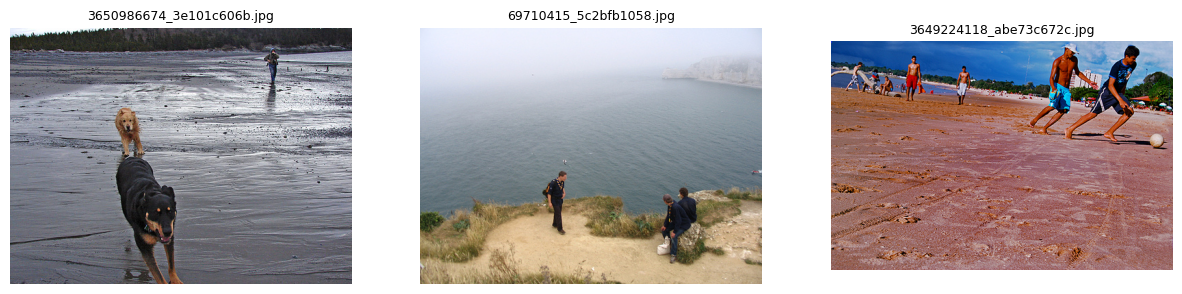

🤖 Thinking...


### 💡 Answer:
Here are the images where you can find a person walking on sand:

*   **Image 1:** There is a person walking in the background, in the distance, on what appears to be a wet, sandy/muddy beach.
*   **Image 3:** In the background of this image, there are several people walking on the sand on the beach.

--------------------------------------------------

🔎 Searching for: 'find a dog which is balck in color and mouth open'...
✅ Found 3 images. Analyzing...


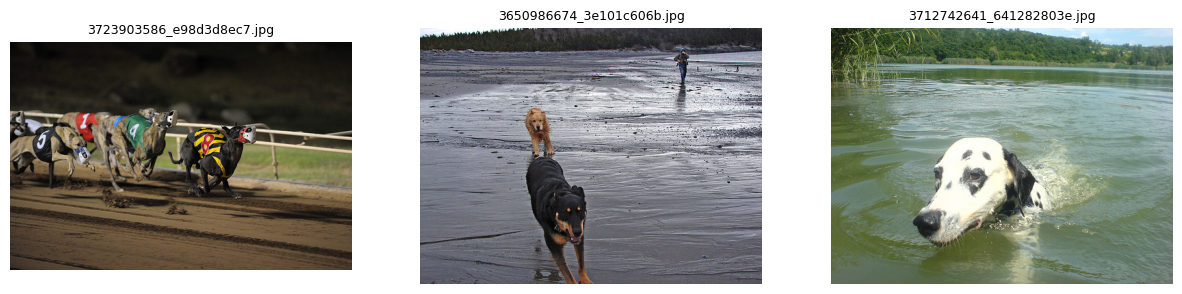

🤖 Thinking...


### 💡 Answer:
The dog in the **second image** (the one running on the wet beach) is black in color and has its mouth open.

--------------------------------------------------

🔎 Searching for: 'find a person running'...
✅ Found 3 images. Analyzing...


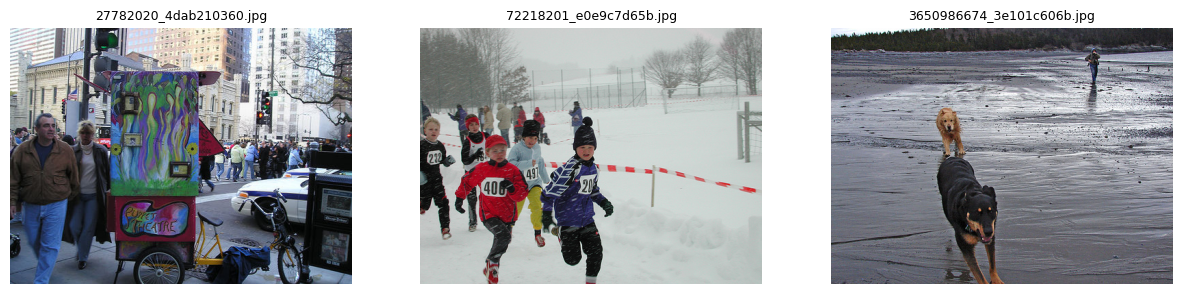

🤖 Thinking...
🚨 API Error: Invalid operation: The `response.text` quick accessor requires the response to contain a valid `Part`, but none were returned. The candidate's [finish_reason](https://ai.google.dev/api/generate-content#finishreason) is 1.
--------------------------------------------------

🔎 Searching for: 'find a pesion who is running'...
✅ Found 3 images. Analyzing...


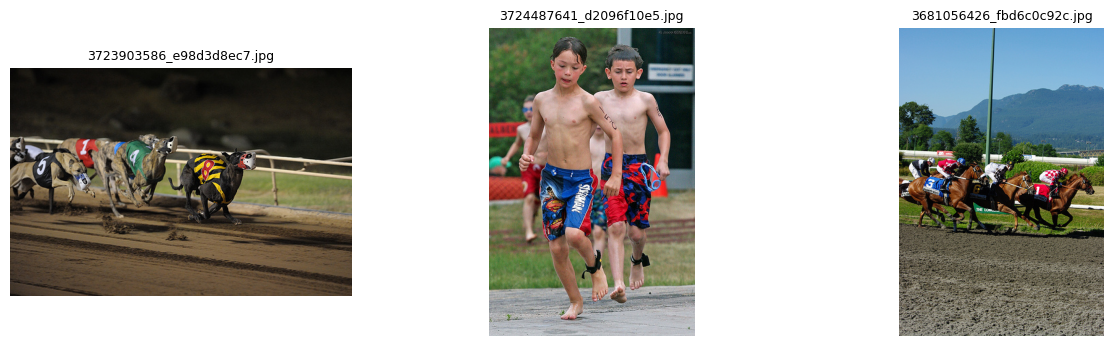

🤖 Thinking...


### 💡 Answer:
The second image shows two young boys who are running. They are barefoot, wearing swim trunks, and appear to be participating in a race or triathlon, given the numbers on their arms and ankle straps.

--------------------------------------------------

🔎 Searching for: 'find a human and wife'...
✅ Found 3 images. Analyzing...


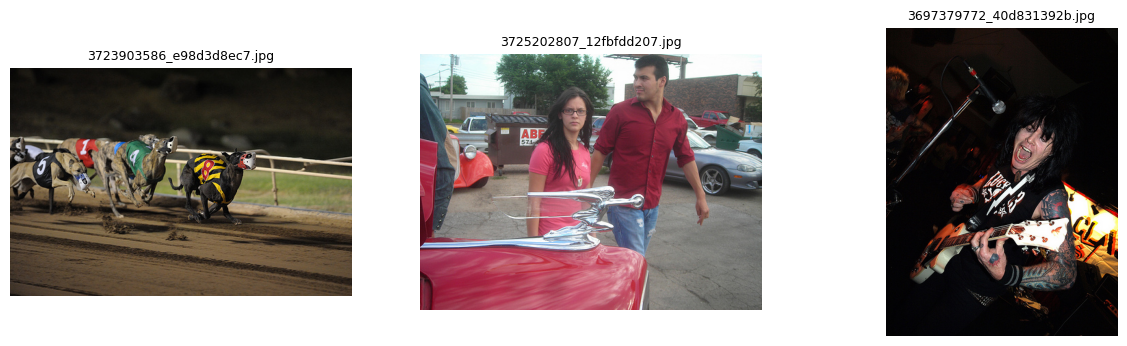

🤖 Thinking...


### 💡 Answer:
The second image shows a man and a woman. The man is on the right, wearing a red shirt and blue jeans, and the woman is on the left, wearing a pink shirt and glasses. They are standing next to a red car and appear to be a couple.

--------------------------------------------------

🔎 Searching for: 'thanks'...
✅ Found 3 images. Analyzing...


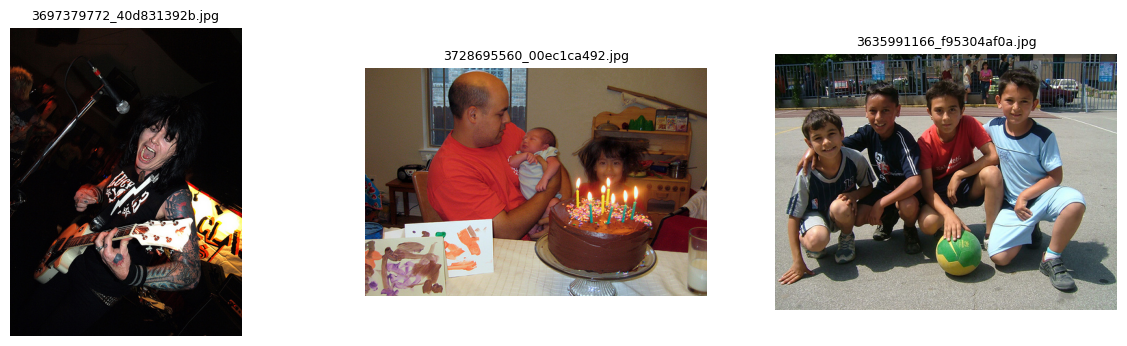

🤖 Thinking...


### 💡 Answer:
Here's an analysis of each image:

**Image 1: The Rock Star**
This image captures a male rock musician in the throes of a performance. He has long, spiky black hair typical of punk or metal genres, and his mouth is wide open in what appears to be a scream or powerful vocal. His face shows intense emotion. He's wearing a black sleeveless t-shirt with a white graphic (possibly a lightning bolt and text), and both arms are heavily adorned with intricate tattoo sleeves. He's playing a white electric guitar, with his left hand gripping the fretboard and his right hand likely strumming or picking (partially obscured). The setting is dark, suggesting a concert venue or club, with a microphone on a stand visible in the background, and another blurry figure to the left. The overall mood is energetic, raw, and intense, characteristic of a live rock show.

**Image 2: Family Birthday Celebration**
This heartwarming scene depicts a family birthday moment. In the foreground, there's a large chocolate birthday cake topped with seven lit candles and colorful sprinkles, sitting on a glass stand. Behind the cake, a young girl with messy dark hair (presumably the birthday child) peeks out, smiling slightly. To the left, several pieces of children's artwork are visible on the table. A bald man, wearing an orange t-shirt, is seated and tenderly cradling a sleeping or very calm infant in his arms, looking down at the baby with a gentle expression. A glass of milk is on the table to the right. The setting appears to be a comfortable home environment, with shelves and a window in the background. The image evokes a feeling of warmth, family love, and quiet celebration.

**Image 3: Boys with a Soccer Ball**
This image features four young boys posing together outdoors on what looks like a concrete or asphalt playground or sports court. All four boys are crouching or squatting and smiling directly at the camera. They appear to be friends, with one boy's arm around another. Each boy is dressed in casual t-shirts and shorts. In the center, a green and yellow soccer ball rests on the ground, with one boy's hand on it. The background shows a metal fence, some blurry figures, and buildings, suggesting an urban or suburban outdoor setting on a sunny day. The overall mood is cheerful, youthful, and represents camaraderie and a love for sports.

--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown, clear_output
import time

def start_rag_loop():
    print("🚀 RAG System Initialized!")
    print("Type 'exit', 'quit', or 'q' to stop.")
    print("-" * 50)

    while True:
        # 1. Get User Input
        try:
            user_query = input("\n📝 Ask a question about your images: ")
        except KeyboardInterrupt:
            print("\n🛑 Loop stopped by user.")
            break
            
        # Check for exit condition
        if user_query.lower() in ['exit', 'quit', 'q']:
            print("👋 Exiting RAG system. Goodbye!")
            break
            
        if not user_query.strip():
            continue

        print(f"\n🔎 Searching for: '{user_query}'...")

        # 2. SEARCH (Retrieval)
        # Encode
        query_vector = model.encode([user_query]).tolist()
        
        # Query ChromaDB
        results = collection.query(
            query_embeddings=query_vector,
            n_results=3  # You can change this to 4 or 5 if you want more context
        )

        # Load Images
        retrieved_imgs = []
        filenames = []
        
        if results['metadatas'][0]:
            for meta in results['metadatas'][0]:
                path = meta['path']
                try:
                    img = Image.open(path)
                    retrieved_imgs.append(img)
                    filenames.append(os.path.basename(path))
                except Exception as e:
                    print(f"⚠️ Could not load image {path}: {e}")
        
        # 3. VISUALIZE (Matplotlib)
        if not retrieved_imgs:
            print("❌ No matching images found. Try a different query.")
            continue
            
        print(f"✅ Found {len(retrieved_imgs)} images. Analyzing...")
        
        # Create the plot
        cols = len(retrieved_imgs)
        fig, axes = plt.subplots(1, cols, figsize=(15, 4))
        if cols == 1: axes = [axes]
        
        for ax, img, fname in zip(axes, retrieved_imgs, filenames):
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(fname, fontsize=9)
        
        plt.show() # This forces the plot to render immediately
        
        # 4. GENERATE (Gemini)
        print("🤖 Thinking...")
        
        try:
            # Construct Payload
            prompt_payload = [user_query, "Analyze these images to answer the user request."] + retrieved_imgs
            
            # Generate
            response = llm.generate_content(prompt_payload)
            
            # Display Markdown Response
            display(Markdown(f"### 💡 Answer:\n{response.text}"))
            
        except Exception as e:
            print(f"🚨 API Error: {e}")
            
        print("-" * 50)



# --- RUN THE LOOP ---
start_rag_loop()